In [ ]:
! pip install photutils

  Using cached photutils-2.2.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (7.0 kB)
  Using cached scipy-1.15.2-cp311-cp311-macosx_14_0_arm64.whl.metadata (61 kB)
Using cached photutils-2.2.0-cp311-cp311-macosx_11_0_arm64.whl (740 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 2.3 MB/s eta 0:00:0000:0100:01m


TO TRIM THE FILES ACCORDINGLY 


In [ ]:
"""
This script trims FITS images for sextractor comparative photometry analysis
by creating a new FITS object based on a
cutout of the original data, ensuring all cutouts are the same pixel size.
"""

import numpy as np
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D


def read_in_fits(infile: str) -> tuple[fits.HDUList, WCS, int]:
    """
    Reads in the FITS file and WCS, returning the HDU list,
    WCS object, and the index of the image HDU.
    """
    hdu = fits.open(infile)
    for i, h in enumerate(hdu):
        if h.data is not None:
            wcs = WCS(h.header)
            return hdu, wcs, i
    raise ValueError(f"No image data found in any HDU of {infile}")


def make_new_fits_file(hdu: fits.hdu.hdulist.HDUList, cutout_object: Cutout2D, outfile: str) -> None:
    """
    Writes the cutout to a new FITS file.
    """
    new_image = fits.PrimaryHDU(data=cutout_object.data, header=cutout_object.wcs.to_header())
    new_hdul = fits.HDUList([new_image])
    new_hdul.writeto(outfile, overwrite=True)


def cut_fits_image_pixel(fits_image: str, position: SkyCoord, size_pix: tuple[int, int], outfile: str) -> None:
    """
    Cuts a FITS image to a specific pixel size at a given sky position.
    """
    hdu, wcs, index = read_in_fits(fits_image)
    cutout = Cutout2D(hdu[index].data, position, size_pix, wcs=wcs, mode='trim')
    make_new_fits_file(hdu, cutout, outfile)


def get_center_of_image(fits_name: str) -> SkyCoord:
    """
    Returns the sky coordinates of the center of the image.
    """
    hdu = fits.open(fits_name)
    for i, h in enumerate(hdu):
        if h.data is not None:
            data = h.data
            y_pix, x_pix = data.shape[0] / 2, data.shape[1] / 2
            wcs = WCS(h.header)
            ra, dec = wcs.pixel_to_world_values(x_pix, y_pix)
            print(f"RA: {ra}, DEC: {dec}")
            return SkyCoord(ra * u.deg, dec * u.deg)
    raise ValueError(f"No image data found in any HDU of {fits_name}")



if __name__ == '__main__':
    INFILE_I = '/Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osj_i_vik2.fits.fz'
    INFILE_I_WEIGHT = '/Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osw_i_vik2.fits.fz'

    INFILE_Z = '/Users/aishwarya/Documents/Lyman_alpha/Z/c4d_210831_053503_osj_z_vik2.fits.fz'
    INFILE_Z_WEIGHT = '/Users/aishwarya/Documents/Lyman_alpha/Z/c4d_210831_053503_osw_z_vik2.fits.fz'

    INFILE_N964 = '/Users/aishwarya/Documents/Lyman_alpha/N964/c4d_210831_050404_osj_N964_vik2.fits.fz'
    INFILE_N964_WEIGHT = '/Users/aishwarya/Documents/Lyman_alpha/N964/c4d_210831_050404_osw_N964_vik2.fits.fz'

    # Pixel size for the cutouts 
    SIZE = (6000, 6000)  # (height, width)

    # Use N964 image to determine central coordinate
    n964_position = get_center_of_image(INFILE_N964)

    # Trim all science and weight images
    cut_fits_image_pixel(INFILE_I, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/I/')
    cut_fits_image_pixel(INFILE_I_WEIGHT, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/i_weight.fits')

    cut_fits_image_pixel(INFILE_Z, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/z.fits')
    cut_fits_image_pixel(INFILE_Z_WEIGHT, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/z_weight.fits')

    cut_fits_image_pixel(INFILE_N964, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/n964.fits')
    cut_fits_image_pixel(INFILE_N964_WEIGHT, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/n964_weight.fits')


RA: 358.0056596371243, DEC: -31.492553848880974


In [66]:
import astropy
print(astropy.__version__)

7.0.1


In [ ]:
! git clone ´https://github.com/TrystanScottLambert/DECam_Photometry/tree/main

Cloning into 'main'...
fatal: repository 'https://github.com/TrystanScottLambert/DECam_Photometry/tree/main/' not found


In [51]:
hdu = fits.open('/Users/aishwarya/Documents/Lyman_alpha/N964/c4d_210831_050404_osj_N964_vik2.fits.fz')

In [57]:
len(hdu)
for hd in hdu[0].header:
    print(hd)

SIMPLE
BITPIX
NAXIS
EXTEND
DATE
ORIGIN
COMMENT
COMMENT
COMMENT
COMMENT
COMMENT
IRAF-TLM
OBJECT
PROCTYPE
PRODTYPE
FILENAME
OBS-LONG
TELESCOP
OBSERVAT
OBS-LAT
OBS-ELEV
INSTRUME
EXPTIME
EXPDUR
OBSID
DATE-OBS
TIME-OBS
MJD-OBS
MJD-END
TIMESYS
OBSTYPE
PROGRAM
OBSERVER
PROPOSER
DTPI
PROPID
AOS
BCAM
GUIDER
FILTER
ERRORS
TELEQUIN
TELSTAT
RA
DEC
TELRA
TELDEC
DOMEAZ
ZPDELRA
ZPDELDEC
TELFOCUS
GSKYPHOT
LSKYPHOT
DIMM2SEE
MASS2
ASTIG1
ASTIG2
AIRMASS
GSKYVAR
GSKYHOT
LSKYVAR
LSKYHOT
LSKYPOW
DONUTFS4
DONUTFS3
DONUTFS2
DONUTFS1
DONUTFN1
DONUTFN2
DONUTFN3
DONUTFN4
TIME_RECORDED
DOXT
FADZ
FADY
FADX
G-MODE
FAYT
DODZ
DODY
DODX
SKYUPDAT
DOYT
LUTVER
FAXT
SISPIVER
CONSTVER
HDRVER
DTNSANAM
DTINSTRU
DTACQNAM
DTPROPID
DTCALDAT
DTSITE
DTTELESC
DETECTOR
CCDNUM
FPA
CCDBIN1
CCDBIN2
DHEINF
DHEFIRM
SLOT00
SLOT01
SLOT02
SLOT03
SLOT04
SLOT05
RADESYS
NDONUTS

PHOTFLAG
DESDCXTK
XTALKFIL
DESOSCN
BIASFIL
BAND
NITE
DESBIAS
LINCFIL
DESLINC
DESBPM
BPMFIL
DESSAT
NSATPIX
FLATMEDA
FLATMEDB
SATURATE
DESGAINC
FLATFIL
DESFLAT
STARFIL


In [45]:
import numpy as np
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D

def read_in_fits(infile: str) -> tuple[fits.HDUList, WCS]:
    hdu = fits.open(infile)
    wcs = WCS(hdu[1].header)
    return hdu, wcs

def make_new_fits_file(hdu: fits.hdu.hdulist.HDUList, cutout_object: Cutout2D, outfile: str) -> None:
    new_primary = fits.PrimaryHDU()
    new_image = fits.ImageHDU(data=cutout_object.data, header=hdu[1].header)
    new_image.header.update(cutout_object.wcs.to_header())
    new_hdul = fits.HDUList([new_primary, new_image])
    new_hdul.writeto(outfile, overwrite=True)

def cut_fits_image_pixel(fits_image: str, position: SkyCoord, size_pix: tuple[int, int], outfile: str) -> None:
    hdu, wcs = read_in_fits(fits_image)
    cutout = Cutout2D(hdu[1].data, position, size_pix, wcs=wcs)
    make_new_fits_file(hdu, cutout, outfile)

def get_center_of_image(fits_name: str) -> SkyCoord:
    hdu = fits.open(fits_name)
    data = hdu[1].data
    y_pix, x_pix = data.shape[0] / 2, data.shape[1] / 2
    wcs = WCS(hdu[1].header)
    ra, dec = wcs.pixel_to_world_values(x_pix, y_pix)
    print(f"RA: {ra}, DEC: {dec}")
    return SkyCoord(ra * u.deg, dec * u.deg)

def get_min_common_image_size(file_list: list[str]) -> tuple[int, int]:
    widths = []
    heights = []
    for f in file_list:
        with fits.open(f) as hdu:
            data = hdu[1].data
            heights.append(data.shape[0])
            widths.append(data.shape[1])
    min_height = min(heights)
    min_width = min(widths)
    return (min_width, min_height)

if __name__ == '__main__':
    INFILE_I = '/Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osj_i_vik2.fits.fz'
    INFILE_I_WEIGHT = '/Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osw_i_vik2.fits.fz'

    INFILE_Z = '/Users/aishwarya/Documents/Lyman_alpha/Z/c4d_210831_053503_osj_z_vik2.fits.fz'
    INFILE_Z_WEIGHT = '/Users/aishwarya/Documents/Lyman_alpha/Z/c4d_210831_053503_osw_z_vik2.fits.fz'

    INFILE_N964 = '/Users/aishwarya/Documents/Lyman_alpha/N964/c4d_210831_050404_osj_N964_vik2.fits.fz'
    INFILE_N964_WEIGHT = '/Users/aishwarya/Documents/Lyman_alpha/N964/c4d_210831_050404_osw_N964_vik2.fits.fz'

    # List of all images to evaluate minimum common size
    ALL_IMAGES = [
        INFILE_I, INFILE_I_WEIGHT,
        INFILE_Z, INFILE_Z_WEIGHT,
        INFILE_N964, INFILE_N964_WEIGHT
    ]

    # Determine the largest cutout size that fits in all images
    SIZE = get_min_common_image_size(ALL_IMAGES)
    print(f"Using cutout size: {SIZE[0]} x {SIZE[1]} pixels")

    # Use N964 science image to determine center
    n964_position = get_center_of_image(INFILE_N964)

    # Cut images
    cut_fits_image_pixel(INFILE_I, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/i.fits')
    cut_fits_image_pixel(INFILE_I_WEIGHT, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/i_weight.fits')

    cut_fits_image_pixel(INFILE_Z, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/z.fits')
    cut_fits_image_pixel(INFILE_Z_WEIGHT, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/z_weight.fits')

    cut_fits_image_pixel(INFILE_N964, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/n964.fits')
    cut_fits_image_pixel(INFILE_N964_WEIGHT, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/n964_weight.fits')


Using cutout size: 9862 x 8979 pixels
RA: 358.0056596371243, DEC: -31.492553848880974


Code to find FWHM

In [9]:
from photutils.detection import DAOStarFinder
from astropy.stats import mad_std
from astropy.io import fits
from astropy.modeling import models, fitting

import numpy as np

# Load the image
image_data = fits.getdata('/Users/aishwarya/Documents/Lyman_alpha/i.fits')
bkg_sigma = mad_std(image_data)

# Detect stars
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*bkg_sigma)
sources = daofind(image_data)

# Choose a bright star to fit a Gaussian (example: first source)
x, y = int(sources['xcentroid'][0]), int(sources['ycentroid'][0])
cutout = image_data[y-5:y+6, x-5:x+6]

# Fit a 2D Gaussian
p_init = models.Gaussian2D(amplitude=cutout.max(), x_mean=5, y_mean=5, x_stddev=2, y_stddev=2)
fit_p = fitting.LevMarLSQFitter()
p = fit_p(p_init, *np.meshgrid(np.arange(cutout.shape[1]), np.arange(cutout.shape[0])), cutout)

# Convert sigma to FWHM
fwhm_x = 2.355 * p.x_stddev.value
fwhm_y = 2.355 * p.y_stddev.value
print(f"FWHM_x = {fwhm_x:.2f} px, FWHM_y = {fwhm_y:.2f} px")


FWHM_x = 945.33 px, FWHM_y = 58982.14 px


[POINT SOURCE] FWHM X: 1.18 px, FWHM Y: 5.14 px, Avg: 3.16 px
→ SEEING_FWHM (point source) in arcsec: 0.85


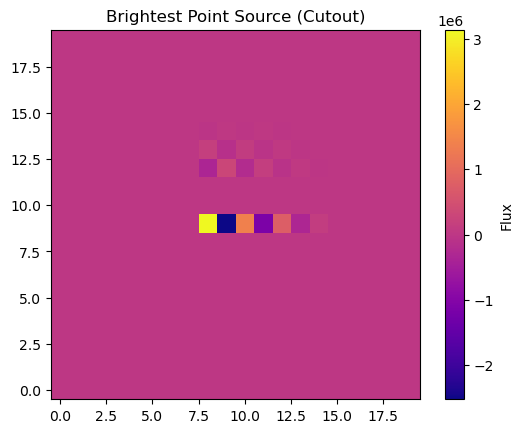

In [13]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.stats import mad_std
from astropy.modeling import models, fitting
from photutils.segmentation import detect_sources
from photutils.segmentation import SourceCatalog
from photutils.background import Background2D, MedianBackground
import numpy as np
import matplotlib.pyplot as plt

# --- Load FITS file ---
fits_name = '/Users/aishwarya/Documents/Lyman_alpha/i.fits'
hdu = fits.open(fits_name)
data = hdu[1].data
header = hdu[1].header
wcs = WCS(header)

# --- Estimate background ---
bkg = Background2D(data, box_size=50, filter_size=(3, 3), bkg_estimator=MedianBackground())
threshold = bkg.background + 2.5 * bkg.background_rms

# --- Detect all sources ---
segm = detect_sources(data, threshold, npixels=5)  # use small npixels to allow for point sources
if segm is None or segm.nlabels == 0:
    raise RuntimeError("No sources detected.")

catalog = SourceCatalog(data, segm, wcs=wcs, background=bkg.background)

# --- Select only point sources ---
# Heuristic: small area and near-circular shape → more likely to be star
point_sources = []
for source in catalog:
    area = source.area.value
    ellipticity = source.ellipticity.value
    if area < 50 and ellipticity < 0.3:  # tweak thresholds if needed
        point_sources.append(source)

if len(point_sources) == 0:
    raise RuntimeError("No point sources detected (based on area and ellipticity criteria).")

# --- Find the brightest point source ---
brightest_point = max(point_sources, key=lambda s: s.max_value)

# --- Make cutout around the point source ---
position_pixel = (brightest_point.xcentroid, brightest_point.ycentroid)
cutout_size = 20  # smaller size is better for isolated point sources
cutout = Cutout2D(data, position=position_pixel, size=cutout_size)

# --- Fit 2D Gaussian ---
y, x = np.mgrid[:cutout.data.shape[0], :cutout.data.shape[1]]
from astropy.modeling import models

initial = models.Gaussian2D(
    amplitude=np.max(cutout.data),
    x_mean=cutout_size / 2, y_mean=cutout_size / 2,
    x_stddev=2, y_stddev=2,
    bounds={"x_stddev": (0.5, 10), "y_stddev": (0.5, 10)}
)

fit_p = fitting.LevMarLSQFitter()
gauss = fit_p(initial, x, y, cutout.data)

# --- FWHM ---
fwhm_x = 2.3548 * gauss.x_stddev.value
fwhm_y = 2.3548 * gauss.y_stddev.value
fwhm_avg = (fwhm_x + fwhm_y) / 2

# --- Pixel scale ---
pixscale = 7.5e-5 * 3600  # arcsec/pixel
fwhm_arcsec = fwhm_avg * pixscale

# --- Output ---
print(f"[POINT SOURCE] FWHM X: {fwhm_x:.2f} px, FWHM Y: {fwhm_y:.2f} px, Avg: {fwhm_avg:.2f} px")
print(f"→ SEEING_FWHM (point source) in arcsec: {fwhm_arcsec:.2f}")

# --- Plot ---
plt.imshow(cutout.data, origin='lower', cmap='plasma')
plt.colorbar(label='Flux')
plt.title('Brightest Point Source (Cutout)')
plt.show()


In [29]:
from astropy.io import fits

fits_name = '/Users/aishwarya/Documents/Lyman_alpha/i.fits'
hdu = fits.open(fits_name)
header = hdu[1].header

# Get pixel scale from header (CDELT1 or CD1_1), convert degrees to arcsec
if 'CDELT1' in header:
    pixel_scale = abs(header['CDELT1']) * 3600  # arcsec/pixel
elif 'CD1_1' in header:
    pixel_scale = abs(header['CD1_1']) * 3600
else:
    raise ValueError("Pixel scale not found in header.")

# Your measured FWHM in pixels
fwhm_avg = 10.45  # replace with your actual FWHM from the fit

# Compute FWHM in arcsec
seeing_fwhm = fwhm_avg * pixel_scale

print(f"→ SEEING_FWHM to use in SExtractor: {seeing_fwhm:.2f} arcsec")


→ SEEING_FWHM to use in SExtractor: 37620.00 arcsec


Masking the catalogs using the created mask from make_mask_fits_file.

In [ ]:
"""Module to cnonvert .cat files into .reg files. Note you can also you the aperture_check.fits"""

import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

def read_in_positions(file_name: str):
    """Reads in the first and second column which are r_a and dec respectively"""
    r_a, dec = np.loadtxt(file_name, usecols=(3, 4), unpack=True)

    
    return r_a, dec

def replace_letter_with_colons(string: str):
    """30d45m64s --> 30:45:64"""
    letters = ('h','d','m')
    for letter in letters:
        string = string.replace(letter, ':')
    return string.replace('s','')

def convert_decimal_degrees_into_celestial(r_a: float, dec: float):
    """Takes floats and returns them in the hh:mm:ss and dd:mm:ss format."""
    coord = SkyCoord(ra = r_a*u.deg, dec = dec*u.deg)
    print(coord.to_string('hmsdms'))
    return replace_letter_with_colons(coord.to_string('hmsdms'))


def convert_cat_to_reg(sextractor_catalog: str, outfile: str = 'sex_cat.reg'):
    """takes a .cat file and returns a .reg file"""
    r_a, dec = read_in_positions(sextractor_catalog)
    positions = [convert_decimal_degrees_into_celestial(r_a[i], dec[i]) for i in range(len(r_a))]
    
    file = open(outfile, 'w', encoding='utf8')
    for pos in positions:
        file.write(f'circle {pos} 2.5" \n')
    file.close()


if __name__ == '__main__':
    INFILE = '/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band.cat'
    convert_cat_to_reg(INFILE,outfile='/Users/aishwarya/Documents/Lyman_alpha/CAT/n964.reg')

ValueError: invalid column index 1 at row 1 with 1 columns

In [1]:
"""Module to cnonvert .cat files into .reg files. Note you can also you the aperture_check.fits"""

import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

def read_in_positions(file_name: str):
    """Reads in RA and Dec columns from a .cat file (comma or space separated)."""
    try:
        # Try comma-delimited first
        r_a, dec = np.loadtxt(file_name, delimiter=",", usecols=(0, 1), unpack=True, skiprows=1)
    except ValueError:
        # Fallback: whitespace-delimited
        r_a, dec = np.loadtxt(file_name, usecols=(0, 1), unpack=True, skiprows=1)
    return r_a, dec


def replace_letter_with_colons(string: str):
    """30d45m64s --> 30:45:64"""
    letters = ('h','d','m')
    for letter in letters:
        string = string.replace(letter, ':')
    return string.replace('s','')

def convert_decimal_degrees_into_celestial(r_a: float, dec: float):
    """Takes floats and returns them in the hh:mm:ss and dd:mm:ss format."""
    coord = SkyCoord(ra = r_a*u.deg, dec = dec*u.deg)
    print(coord.to_string('hmsdms'))
    return replace_letter_with_colons(coord.to_string('hmsdms'))


def convert_cat_to_reg(sextractor_catalog: str, outfile: str = 'sex_cat.reg'):
    """takes a .cat file and returns a .reg file"""
    r_a, dec = read_in_positions(sextractor_catalog)
    positions = [convert_decimal_degrees_into_celestial(r_a[i], dec[i]) for i in range(len(r_a))]
    
    file = open(outfile, 'w', encoding='utf8')
    for pos in positions:
        file.write(f'circle {pos} 2.5" \n')
    file.close()


if __name__ == '__main__':
    INFILE = '/Users/aishwarya/Documents/Lyman_alpha/LAE_candidates.cat'
    convert_cat_to_reg(INFILE,outfile='/Users/aishwarya/Documents/Lyman_alpha/CAT/LAE.reg')

23h50m40.637664s -31d48m16.44228s
23h49m20.572632s -31d48m17.27892s
23h49m16.490976s -31d48m04.21596s
23h49m18.189528s -31d47m44.43072s
23h50m41.72724s -31d47m37.68468s
23h49m16.536144s -31d47m03.3936s
23h49m25.372776s -31d46m34.90248s
23h47m45.98496s -31d45m43.71372s
23h47m46.283112s -31d45m40.4658s
23h49m23.27988s -31d45m31.62348s
23h50m42.703872s -31d45m27.21852s
23h47m45.402s -31d45m29.44008s
23h47m46.00488s -31d45m27.04104s
23h47m46.184736s -31d45m24.03216s
23h47m45.568608s -31d45m08.91828s
23h47m44.289432s -31d45m04.94856s
23h47m26.51796s -31d44m28.95468s
23h46m26.583336s -31d44m20.88276s
23h47m46.335696s -31d44m21.5052s
23h47m46.773552s -31d44m20.62824s
23h46m23.615976s -31d44m13.63632s
23h49m17.068536s -31d44m14.77176s
23h47m28.136616s -31d44m12.30756s
23h46m23.353608s -31d44m07.09404s
23h47m45.290088s -31d44m07.89036s
23h47m28.267128s -31d44m06.64656s
23h49m22.730256s -31d44m08.00016s
23h47m28.286376s -31d44m07.79712s
23h47m28.045392s -31d44m05.85168s
23h47m45.5256s -31d43m57.

In [12]:
"""
Convert .cat files with RA/Dec in sexagesimal format into DS9 .reg files.
Assumes .cat file has two columns: RA Dec (strings like 23:48:33.33 -30:54:10.23).
"""

import numpy as np

def read_in_positions(file_name: str):
    """Reads RA and Dec columns from a .cat file (comma or space separated)."""
    try:
        data = np.genfromtxt(file_name, delimiter=",", dtype=str)
    except Exception:
        data = np.genfromtxt(file_name, dtype=str)
    return data[:, 0], data[:, 1]

def convert_cat_to_reg(sextractor_catalog: str, outfile: str = 'sex_cat.reg', radius: float = 2.5):
    """
    Convert a .cat file into a DS9 .reg file with circle regions.
    Parameters
    ----------
    sextractor_catalog : str
        Input catalog with RA, Dec in sexagesimal strings.
    outfile : str
        Output .reg file path.
    radius : float
        Circle radius in arcsec.
    """
    r_a, dec = read_in_positions(sextractor_catalog)

    with open(outfile, 'w', encoding='utf-8') as file:
        file.write("# Region file format: DS9 version 4.1\n")
        file.write("fk5\n")
        for ra, d in zip(r_a, dec):
            file.write(f"circle({ra},{d},{radius}\")\n")

if __name__ == '__main__':
    INFILE = '/Users/aishwarya/Documents/Lyman_alpha/LAE_candidates.cat'
    OUTFILE = '/Users/aishwarya/Documents/Lyman_alpha/CAT/LAE.reg'
    convert_cat_to_reg(INFILE, outfile=OUTFILE, radius=20.5)


In [61]:
"""
This script reduces sex catalogs to only include sources within a specified region.
It uses the Pyregion package to define the region of interest based on a DS9 region file,
and applies the mask to the input catalogs using numpy arrays.
The edited catalogs are then overwritten in place.

Dependencies:
- Pyregion
- numpy

Usage:
- Ensure that the Pyregion and numpy packages are installed.
- Define the path to the DS9 region file and the input catalogs.
- Run the script.
"""

import glob
from regions import PixCoord, PolygonPixelRegion
import numpy as np


def load_region(file_name: str):
    """
    Reads in a ds9 region file and returns a PolygonPixelRegion object.

    Parameters
    ----------
    file_name : str
        The name of the ds9 region file to load.

    Returns
    -------
    region_pix : `~regions.PolygonPixelRegion`
        The PolygonPixelRegion object representing the loaded region.

    """
    vertices = parse_ds9_region_file(file_name)
    x_pix, y_pix = split_xy(vertices)
    vertices = PixCoord(x=x_pix, y=y_pix)
    region_pix = PolygonPixelRegion(vertices=vertices)
    return region_pix

def parse_ds9_region_file(file_name:str) -> np.ndarray:
    """
    Returns an array of vertices from a ds9 region file.

    Parameters
    ----------
    file_name : str
        The name of the ds9 region file to load.

    Returns
    -------
    vertices_float : numpy.ndarray
        The array of vertices as floats.

    """
    with open(file_name, encoding='utf8') as file:
        lines = file.readlines()
    verticies_string = lines[-1].split('(')[-1].split(')')[0].split(',')
    verticies_float = np.array(verticies_string).astype(float)
    return verticies_float

def split_xy(verticies: np.ndarray) -> tuple:
    """
    Splits an array of vertices into separate x and y arrays.

    Parameters
    ----------
    vertices : numpy.ndarray
        The array of vertices.

    Returns
    -------
    tuple
        A tuple of two numpy.ndarray objects, the x and y arrays.

    """
    x_pix,y_pix = [],[]
    for i, _ in enumerate(verticies):
        if i%2 == 0:
            x_pix.append(verticies[i])
        elif i%2 == 1:
            y_pix.append(verticies[i])
    return x_pix, y_pix


def is_pixel_within_region(x_coord, y_coord, region):
    """
    Returns True if the given pixel is inside the specified region.

    Args:
        x_coord (float): The x-coordinate of the pixel.
        y_coord (float): The y-coordinate of the pixel.
        region (PolygonPixelRegion): The region to test against.

    Returns:
        bool: True if the pixel is inside the region, False otherwise.
    """
    return PixCoord(x_coord, y_coord) in region

def get_region_mask(x_array: np.ndarray, y_array: np.ndarray, region: PolygonPixelRegion) -> list[bool]:
    """
    Returns a boolean mask indicating which pixels are inside the specified region.

    Args:
        x_array (numpy.ndarray): The x-coordinates of the pixels.
        y_array (numpy.ndarray): The y-coordinates of the pixels.
        region (PolygonPixelRegion): The region to test against.

    Returns:
        numpy.ndarray: A boolean mask indicating which pixels are inside the region.
    """
    mask = [is_pixel_within_region(x_array[i], y_array[i], region) for i in range(len(x_array))]
    return mask

def get_header_body(input_file: str):
    """
    Separates the header and body of an ASCII file.

    Args:
        input_file (str): The path to the input file.

    Returns:
        Tuple[list[str], list[str]]: A tuple containing the header lines and the body lines of the file.
    """
    with open(input_file, encoding='utf8') as file:
        lines = file.readlines()

    header = [line for line in lines if line.startswith('#')]
    body = [line for line in lines if not line.startswith('#')]
    return header, body

class Catalog:
    """A class to read, edit, and write sex catalogs based on a specified region.

    Attributes:
    -----------
    input_file : str
        Path to the input catalog file.
    header : list
        List of header lines in the input catalog.
    body : list
        List of body lines in the input catalog.
    x_array : numpy.ndarray
        Array of x-coordinates from the input catalog.
    y_array : numpy.ndarray
        Array of y-coordinates from the input catalog.
    region : regions.PolygonPixelRegion
        Region of interest, defined by a DS9 region file and loaded as a PolygonPixelRegion object using Pyregion.
    mask : list of bool
        List of True/False values indicating whether each source in the catalog falls within the specified region.

    Methods:
    --------
    reduce_body():
        Removes rows from the body of the catalog that correspond to sources outside of the specified region.
    write_catalog():
        Overwrites the input catalog with the reduced version.
    """
    def __init__(self, input_file:str, region: str):
        """
        Parameters:
        -----------
        input_file : str
            Path to the input catalog file.
        region : str
            Path to the DS9 region file defining the region of interest.
        """
        self.input_file = input_file
        self.header, self.body = get_header_body(input_file)
        self.x_array, self.y_array = np.loadtxt(self.input_file, usecols=(2,3), unpack=True)
        self.region = load_region(region)
        self.mask = get_region_mask(self.x_array, self.y_array, self.region)
        self.reduce_body()
        self.write_catalog()

    def reduce_body(self):
        """
        Updates the body of the catalog to include only those rows corresponding
        to sources within the region of interest.

        Returns:
        None
        """
        self.body = list(np.array(self.body)[self.mask])

    def write_catalog(self):
        """
        Writes the edited catalog to the original input file, overwriting its
        contents. The file is opened in 'w' mode, so any previous contents of
        the file will be erased.

        Returns:
        None
        """
        with open(self.input_file, 'w', encoding='utf8') as file:
            for line in self.header:
                file.write(line)

            for line in self.body:
                file.write(line)


if __name__ == '__main__':
    REGION_FILE = '/Users/aishwarya/Documents/Lyman_alpha/n964.reg'
    infiles = glob.glob('/Users/aishwarya/Documents/Lyman_alpha/*.cat')

    for file in infiles:
        Catalog(file, REGION_FILE)

ValueError: could not convert string to float: np.str_('circle 23:51:18.894696 -31:16:23.19276 2.5" \n')

In [ ]:
"""
Making a masked fits file for our decam field
"""

from astropy.io import fits
from regionfy_catalog import load_region

FITS_FILE = '/Users/aishwarya/Documents/Lyman_alpha/cat/n964.fits'
REGION_FILE = '/Users/aishwarya/Documents/Lyman_alpha/cat/n964.reg'


image = fits.open(FITS_FILE)
region_decam_fov = load_region(REGION_FILE)
print('making mask')
region_decam_mask = region_decam_fov.to_mask()
print('converting to image')
region_image = region_decam_mask.to_image(image[0].data.shape)
print('mask done, writing to file')
image[0].data = region_image
image.writeto('DECAM_MASK.fits', overwrite=True)

ValueError: could not convert string to float: np.str_('00:08:00 -31:21:02.84472')

In [ ]:
# Load image and WCS
FITS_FILE = '/Users/aishwarya/Documents/Lyman_alpha/n964.fits'
REGION_FILE = '/Users/aishwarya/Documents/Lyman_alpha/n964.reg'


In [35]:
"""
Making a masked fits file for our decam field
"""

from astropy.io import fits
from regionfy_catalog import load_region

FITS_FILE = '/Users/aishwarya/Documents/Lyman_alpha/n964.fits'
REGION_FILE = '/Users/aishwarya/Documents/Lyman_alpha/n964.reg'

image = fits.open(FITS_FILE)
region_decam_fov = load_region(REGION_FILE)
print('making mask')
region_decam_mask = region_decam_fov.to_mask()
print('converting to image')
region_image = region_decam_mask.to_image(image[0].data.shape)
print('mask done, writing to file')
image[0].data = region_image
image.writeto('DECAM_MASK.fits', overwrite=True)

ValueError: could not convert string to float: np.str_('00:08:00 -31:21:02.84472')

In [8]:
from astropy.io import fits
from astropy.wcs import WCS
from regions import Regions

FITS_FILE = '/Users/aishwarya/Documents/Lyman_alpha/n964.fits'
REGION_FILE = '/Users/aishwarya/Documents/Lyman_alpha/n964.reg'

# Open the FITS file and get WCS
with fits.open(FITS_FILE) as hdul:
    image_data = hdul[0].data
    header = hdul[0].header
    wcs = WCS(header)

# Load regions from file
regions = Regions.read(REGION_FILE, format='ds9')

# Convert to pixel regions using WCS
pixel_regions = [r.to_pixel(wcs) for r in regions]

# Make mask from pixel regions
from numpy import zeros_like
mask = zeros_like(image_data, dtype=bool)

for region in pixel_regions:
    mask |= region.to_mask(mode='center').to_image(image_data.shape).astype(bool)

# Save the mask as a new FITS file
hdu = fits.PrimaryHDU(mask.astype(float), header=header)
hdu.writeto('DECAM_MASK.fits', overwrite=True)


ValueError: Number of world inputs (1) does not match expected (2)

In [7]:
import glob
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from regions import Regions, PixCoord
from regions.core import PixelRegion

def get_header_body(input_file: str):
    with open(input_file, encoding='utf8') as file:
        lines = file.readlines()
    header = [line for line in lines if line.startswith('#')]
    body = [line for line in lines if not line.startswith('#')]
    return header, body

def is_pixel_within_region(x, y, region: PixelRegion):
    coord = PixCoord(x=x, y=y)
    return coord in region

def get_region_mask(x_array: np.ndarray, y_array: np.ndarray, region: PixelRegion):
    return np.array([is_pixel_within_region(x, y, region) for x, y in zip(x_array, y_array)])

class Catalog:
    def __init__(self, input_file: str, region_file: str, fits_file: str):
        self.input_file = input_file
        self.header, self.body = get_header_body(input_file)
        
        # Read source positions (x, y in pixels)
        self.x_array, self.y_array = np.loadtxt(input_file, usecols=(2, 3), unpack=True)
        
        # Load WCS from FITS file
        with fits.open(fits_file) as hdul:
            wcs = WCS(hdul[0].header)
        
        # Read regions and convert to pixel coordinates
        regions = Regions.read(region_file, format='ds9')
        pixel_regions = [r.to_pixel(wcs) for r in regions]
        
        # Use first region only (or modify if multiple)
        self.region = pixel_regions[0]
        
        # Get mask and filter catalog
        self.mask = get_region_mask(self.x_array, self.y_array, self.region)
        self.reduce_body()
        self.write_catalog()

    def reduce_body(self):
        self.body = list(np.array(self.body)[self.mask])

    def write_catalog(self):
        with open(self.input_file, 'w', encoding='utf8') as file:
            for line in self.header:
                file.write(line)
            for line in self.body:
                file.write(line)

if __name__ == '__main__':
    REGION_FILE = 'DECAM.reg'  # DS9 region file (FK5 or image coords)
    FITS_FILE = 'n964.fits'    # Corresponding FITS image with valid WCS
    CATALOGS = glob.glob('../correct_stacks/N964/*.cat')

    for catfile in CATALOGS:
        Catalog(catfile, REGION_FILE, FITS_FILE)


In [22]:
"""
Masking the catalogs using the created mask from make_mask_fits_file.
"""

import glob
from astropy.io import fits
import numpy as np

def get_header_body(input_file: str) -> tuple[list[str], list[str]]:
    """
    Separates the header and body of an ASCII file.

    Args:
        input_file (str): The path to the input file.

    Returns:
        Tuple[list[str], list[str]]: A tuple containing the header lines
        and the body lines of the file.
    """
    with open(input_file, encoding='utf8') as file:
        lines = file.readlines()

    header = [line for line in lines if line.startswith('#')]
    body = [line for line in lines if not line.startswith('#')]
    return header, body


class Mask:
    """
    Masks made by the maske_mask_fits_file.py These masks are fits files with 
    0 representing areas that are masked and 1s areas that are not.
    """
    def __init__(self, infile: str) -> None:
        """Initilizing"""
        self.hdu = fits.open(infile)
        self.data = self.hdu[0].data

    def is_pix_good(self, x_val: int, y_val: int) -> bool:
        """Determines if a given point is masked."""
        good = True
        if self.data[y_val-1, x_val-1] == 0:
            good = False
        return good

def mask_xy_vals(x_array: np.ndarray, y_array: np.ndarray, mask: Mask) -> list[bool]:
    """Loops through all values and determines if they are masked or not."""
    mask = [mask.is_pix_good(int(x_val), int(y_val)) for x_val, y_val in zip(x_array, y_array)]
    return mask


class Catalog:
    """Catalogs"""
    def __init__(self, infile: str) -> None:
        """Initilizing"""
        self.infile = infile
        self.header, self.body = get_header_body(self.infile)
        self.x_array, self.y_array = np.loadtxt(infile, usecols=(2,3), unpack=True)

    def mask_values(self, mask: Mask) -> None:
        """Masks the current values."""
        val_mask = mask_xy_vals(self.x_array, self.y_array, mask)
        self.body = list(np.array(self.body)[val_mask])

    def write_catalog(self) -> None:
        """
        Writes the edited catalog to the original input file, overwriting its
        contents. The file is opened in 'w' mode, so any previous contents of
        the file will be erased.

        Returns:
        None
        """
        with open(self.infile, 'w', encoding='utf8') as file:
            for line in self.header:
                file.write(line)

            for line in self.body:
                file.write(line)

if __name__ == '__main__':
    MASK_NAME = 'DECAM_MASK.fits'
    catalogs = glob.glob('/Users/aishwarya/Documents/Lyman_alpha/cat/*.cat')
    cdfs_mask = Mask(MASK_NAME)

    for catalog in catalogs:
        cat = Catalog(catalog)
        cat.mask_values(cdfs_mask)
        cat.write_catalog()

FileNotFoundError: [Errno 2] No such file or directory: 'DECAM_MASK.fits'